# Calculate Exceedance

Code compiled from clee

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import sys
import os, glob
import xarray as xr


## most correct would probably be to seperate this... 
### get variables from chaz run
import Namelist as gv

### TEMPORARY (hopefully) code snippet so that the HTML view of datasets/dataarrays is viewable in darkmode on jupyter lab/VS code
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

In [2]:
## from clee chazchecks.py
# def exceedence(filename):
# 	dspy = xr.open_dataset(filename)
# 	#dspy = ds
# 	#figname = Path(filename).stem
# 	Vmax = np.nanmax(dspy.Mwspd,axis=1)
# 	Vmax = Vmax[~np.isnan(Vmax)]
# 	bins = np.arange(30,200,step=10)
# 	freq = []
# 	for i in bins:
# 		greaterthan = (np.asarray(Vmax)>i).sum()
# 		y = greaterthan/len(Vmax)
# 		freq.append(y)
# 	plt.figure(figsize=(6, 5))
# 	plt.bar(bins,freq,width=7,edgecolor='k',color='royalblue')
# 	plt.xlabel('Intensity(kt)',size=15)
# 	plt.xticks(bins)
# 	plt.ylabel('Frequency',size=15)
# 	#filename = figname+'exceedence.png'
# 	#plt.savefig(uniquify(filename))

# 	return()

In [3]:
version_configs = {
    'ERA5-Original-CHAZ': {
        'base_dir': "/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/",
        "year_range": (1950, 2020),     
        "output_dir": gv.output_path,
        "file_pattern": "global_2019_2ens*_pre.nc",
        "name": 'ERA5-Original-CHAZ',
        
    },
    'ERA5-Updated-CHAZ': {
        'base_dir': gv.output_path,
        "year_range": (gv.Year1, gv.Year2),
        "file_pattern": "ERA5_*_ens0*.nc",
        "output_dir": gv.output_path,
        "name": 'ERA5-Updated-CHAZ',
    }
}

def _get_basin_mask(latitude, longitude, basin):
    """
    Determine which storms have at least one track point inside a selected ocean basin.

    latitude, longitude:
        xarray.DataArray with dimensions (lifelength, stormID)

    Returns:
        1-D boolean numpy array with length stormID
    """

    if basin == 'ATL':
        # ~100°W–20°E, 0–60°N
        point_mask = (
            (latitude >= 0) &
            (latitude <= 60) &
            (
                (longitude >= 260) |
                (longitude <= 20)
            )
        )

    elif basin == 'WNP':
        # ~100°E–180°E, 0–50°N
        point_mask = (
            (latitude >= 0) &
            (latitude <= 50) &
            (longitude >= 100) &
            (longitude <= 180)
        )

    elif basin == 'GLOBAL':
        # 0–360°, -60–60°
        point_mask = (
            (latitude >= -60) &
            (latitude <= 60)
        )

    else:
        raise ValueError(
            f"Unknown basin: {basin}. "
            "Choose from 'ATL', 'WNP', or 'GLOBAL'."
        )

    ## A storm counts as 'in the ocean basin' if ANY part of its track is within the basin.
    storm_mask = point_mask.any(dim='lifelength')

    return storm_mask.values


def _enumerate_files(cfg):
    base_dir      = cfg["base_dir"]
    file_pattern  = cfg["file_pattern"]
    name          = cfg["name"]
    year_range    = cfg["year_range"]

    filenames = glob.glob(os.path.join(base_dir, file_pattern))
    years_span = year_range[1] - year_range[0] + 1

    if name == 'ERA5-Updated-CHAZ':
        years = {str(y) for y in range(year_range[0], year_range[1] + 1)}
        fnames = sorted([
            f for f in filenames
            if f.split('_')[1] in years])

        nyears_eff = len(fnames)

    elif name == 'ERA5-Original-CHAZ':
        fnames = sorted(filenames)
        nyears_eff = years_span * max(1, len(fnames))

    else:
        raise ValueError(f"Unknown configuration: {name}")

    #return fnames   
    return fnames, nyears_eff


def get_vmax(filenames, basin):
    """Read all files and return maximum wind speed for each storm/event."""

    vmax_all = []

    for filename in filenames:
        print(f"Reading: {filename}")

        with xr.open_dataset(filename) as ds:
            # lat/lon are data variables associated with stormID
            lat = ds.latitude
            lon = ds.longitude

            basin_mask = _get_basin_mask(
                lat,
                lon,
                basin
            )

            # Mwspd dimensions: (ensembleNum, lifelength, stormID)
            #
            # Find maximum over storm lifetime.
            # vmax dimensions: (ensembleNum, stormID)
            vmax = ds.Mwspd.max(dim='lifelength', skipna=True)

            # Keep only storms in selected basin
            vmax = vmax[:, basin_mask]

            # Remove NaNs
            vmax = vmax.values
            vmax = vmax[~np.isnan(vmax)]

            vmax_all.append(vmax)

    if not vmax_all:
        raise ValueError("No valid data found.")

    return np.concatenate(vmax_all)


def plot_exceedance(basin):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        'ERA5-Original-CHAZ': 'royalblue',
        'ERA5-Updated-CHAZ': 'darkorange',
    }

    for name, cfg in version_configs.items():

        filenames, nyears_eff = _enumerate_files(cfg)

        print(
            f"{name}: "
            f"{len(filenames)} files, "
            f"{nyears_eff} effective years"
        )

        vmax = get_vmax(filenames, basin)

        bins = np.arange(30, 200, 10)

        # Number of storms exceeding each threshold
        # divided by number of years represented
        annual_exceedance = np.array([
            np.sum(vmax > threshold) / nyears_eff
            for threshold in bins
        ])

        ax.plot(
            bins,
            #freq,
            annual_exceedance,
            marker='o',
            linewidth=2,
            color=colors[name],
            label=name
        )

    ax.set_xlabel('Intensity (kt)')
    ax.set_ylabel(f'Annual Exceedance Frequency - {basin} ')
    ax.set_xticks(bins)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

ERA5-Original-CHAZ: 60 files, 4260 effective years
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens001_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens002_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens003_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens004_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens005_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens006_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens007_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens008_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens009_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens010_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir

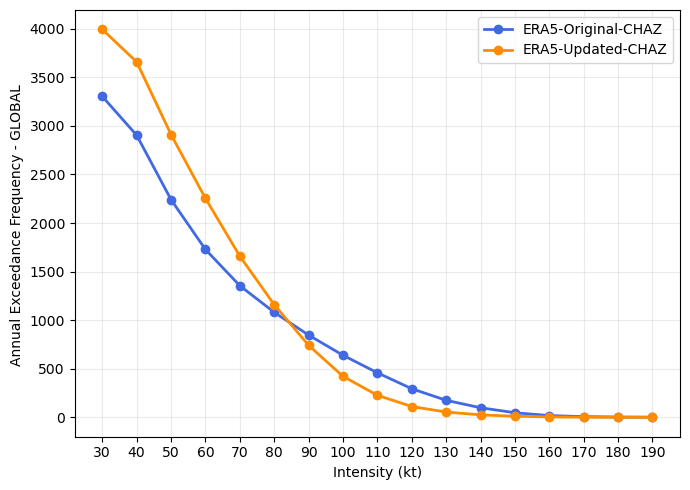

ERA5-Original-CHAZ: 60 files, 4260 effective years
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens001_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens002_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens003_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens004_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens005_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens006_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens007_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens008_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens009_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens010_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir

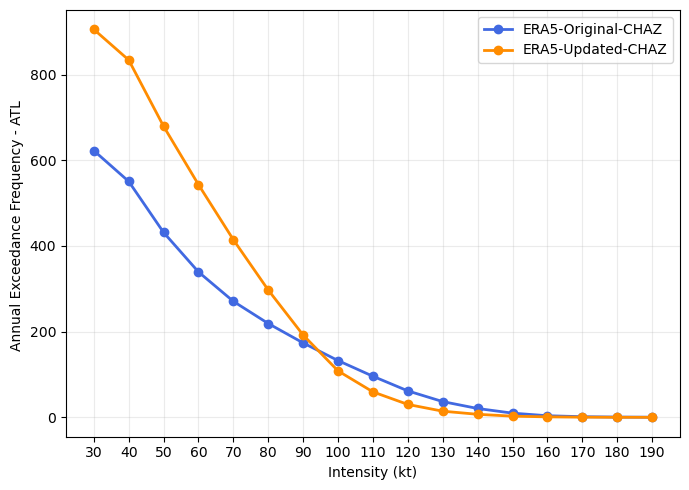

ERA5-Original-CHAZ: 60 files, 4260 effective years
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens001_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens002_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens003_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens004_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens005_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens006_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens007_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens008_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens009_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens010_pre.nc
Reading: /xpt/taroko.local/data0/clee/ERA5/wdir

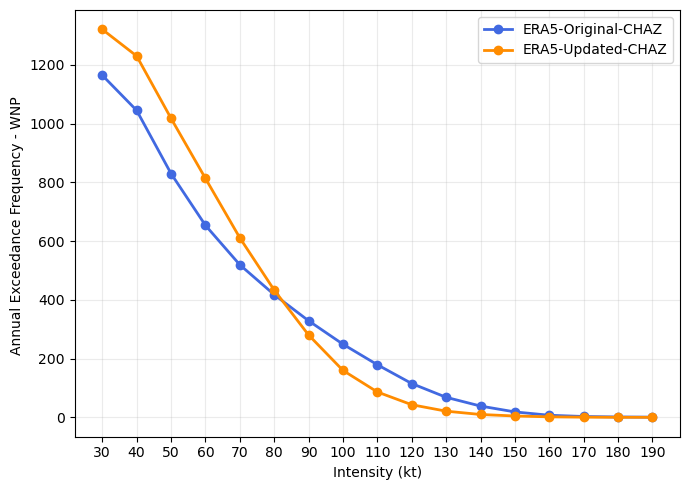

In [4]:
plot_exceedance(basin = 'GLOBAL')
plot_exceedance(basin = 'ATL')
plot_exceedance(basin = 'WNP')

In [5]:
fnames_new, nyears_new = _enumerate_files(version_configs['ERA5-Updated-CHAZ'])

ds_orig = xr.open_dataset('/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc')
ds_upd8 = xr.open_dataset(fnames_new[0])

In [6]:
ds_orig

<xarray.Dataset> Size: 393MB
Dimensions:    (lifelength: 125, stormID: 8355, ensembleNum: 40)
Dimensions without coordinates: lifelength, stormID, ensembleNum
Data variables:
    time       (lifelength, stormID) datetime64[ns] 8MB ...
    longitude  (lifelength, stormID) float64 8MB ...
    latitude   (lifelength, stormID) float64 8MB ...
    Mwspd      (ensembleNum, lifelength, stormID) float64 334MB ...
    ushear     (lifelength, stormID) float64 8MB ...
    vshear     (lifelength, stormID) float64 8MB ...
    PIWspd     (lifelength, stormID) float64 8MB ...
    rh         (lifelength, stormID) float64 8MB ...
    year       (stormID) int32 33kB ...

In [7]:
ds_orig.load()

<xarray.Dataset> Size: 393MB
Dimensions:    (lifelength: 125, stormID: 8355, ensembleNum: 40)
Dimensions without coordinates: lifelength, stormID, ensembleNum
Data variables:
    time       (lifelength, stormID) datetime64[ns] 8MB 1951-01-18 ... 1800-0...
    longitude  (lifelength, stormID) float64 8MB 130.1 117.8 116.8 ... nan nan
    latitude   (lifelength, stormID) float64 8MB -8.71 14.01 -17.62 ... nan nan
    Mwspd      (ensembleNum, lifelength, stormID) float64 334MB 25.0 nan ... nan
    ushear     (lifelength, stormID) float64 8MB -9.564 9.775 ... nan nan
    vshear     (lifelength, stormID) float64 8MB -0.7476 4.904 ... nan nan
    PIWspd     (lifelength, stormID) float64 8MB 150.8 122.7 144.2 ... nan nan
    rh         (lifelength, stormID) float64 8MB 70.63 51.72 43.32 ... nan nan
    year       (stormID) int32 33kB 1951 1951 1951 1951 ... 2019 2019 2019 2019

In [8]:
ds_upd8.load()

<xarray.Dataset> Size: 5MB
Dimensions:      (lifelength: 125, stormID: 119, ensembleNum: 40)
Coordinates:
  * lifelength   (lifelength) int64 1kB 0 1 2 3 4 5 ... 119 120 121 122 123 124
  * stormID      (stormID) int64 952B 0 1 2 3 4 5 6 ... 113 114 115 116 117 118
  * ensembleNum  (ensembleNum) int64 320B 0 1 2 3 4 5 6 ... 33 34 35 36 37 38 39
Data variables:
    longitude    (lifelength, stormID) float64 119kB 121.7 122.4 ... nan nan
    latitude     (lifelength, stormID) float64 119kB -15.72 -9.32 ... nan nan
    Mwspd        (ensembleNum, lifelength, stormID) float64 5MB nan 25.0 ... nan
    year         (stormID) int64 952B 1950 1950 1950 1950 ... 1950 1950 1950
    time         (lifelength, stormID) datetime64[ns] 119kB 1950-01-27 ... 18...

In [9]:

### Alt way to import files -- probably eventulally should reformat everythign to export all years for each ens as a single .nc
### need to update to support multiple track realizations for updated data 


## ORIGINAL
## n.b. July 22nd figures in slide dek are a mix of ens000 and ens059, but results are largely similar
ds_old_tmp = xr.open_dataset('/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/global_2019_2ens000_pre.nc').load()
mask = (ds_old_tmp['year'] >= 2000) & (ds_old_tmp['year'] <= 2009)
ds_old = ds_old_tmp.isel(stormID=mask)


### UPDATED
def preprocess(ds):
    # each file's `year` variable is constant across stormID, so grab the first value
    yr = int(ds['year'].values[0])
    return ds.expand_dims(year_dim=[yr])

## cheeky way to just get 2000-2009 (for now)
filenames = sorted(glob.glob('output/ERA5_200*_ens000.nc'))

ds_new = xr.open_mfdataset(
    filenames,
    preprocess=preprocess,
    combine="nested",
    concat_dim="year_dim",
).load()